In [5]:
import numpy as np
import PyWSINDy_ODE.wsindy as ws
import PyWSINDy_ODE.ODE_examples as ODE_examples 
import matplotlib.pylab as plt
from scipy.integrate import solve_ivp

from agl_helpers import addNoise, recoverDynamics

True The solver successfully reached the end of the integration interval. 29.990000000000002 (3000, 7)


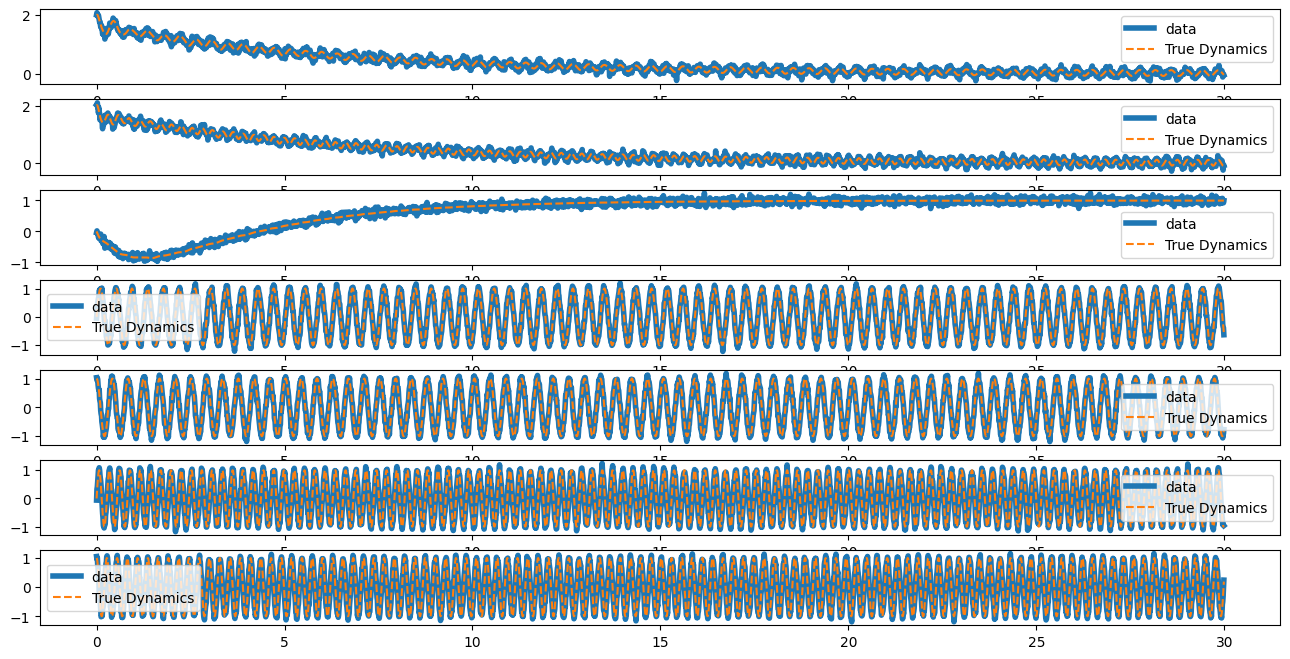

In [6]:
t_span = np.array([0,30])
t_eval = np.arange(0,30,0.01)
noise_ratio = 0.1

# extremum seeking parameters
alpha = 0.1 #dither amplitude
omega_x = 15 #x dither frequency
omega_y = 23 #y dither frequency
omega_n = 1 #high pass filter cutoff frequency
k = 3  #learning rate

#cost function parameters
qx = 0.5
qy = 0.5
f_star = 1.0

def rhs(t, z):
            
            x, y, eta, mx, cx, my, cy = z

            J = f_star - qx*x**2 - qy*y**2 #quadratic cost function
            e = J - eta

            dx = k*e*mx + alpha*omega_x*cx
            dy = k*e*my + alpha*omega_y*cy
            deta = omega_n*e

            dmx = omega_x*cx
            dcx = -omega_x*mx
            dmy = omega_y*cy
            dcy = -omega_y*my

            return np.array([dx, dy, deta, dmx, dcx, dmy, dcy])

x0 = np.array([
    2, #x initial
    2, #y initial
    0, #eta
    np.sin(omega_x*t_span[0]),
    np.cos(omega_x*t_span[0]),
    np.sin(omega_y*t_span[0]),
    np.cos(omega_y*t_span[0]),
])


sol = solve_ivp(fun=rhs, t_eval=t_eval, t_span=t_span, y0=x0, rtol=1e-6)
print(sol.success, sol.message, sol.t[-1], sol.y.T.shape)


x = sol.y.T
t = sol.t
xobs = addNoise(x=sol.y.T,noise_ratio=noise_ratio)

# plt.plot(sol.t,xobs)
fig = plt.figure(figsize=(16, 8))
c = 1
n = xobs.shape[1]
for d in range(n):
    plt.subplot(n, 1, c)
    plt.plot(t, xobs[:, d], label = "data", linewidth = 4)
    plt.plot(t, x[:, d], "--", label = 'True Dynamics',)
    c = c + 1
    plt.legend()

In [7]:
WSINDy_model = ws.wsindy(polys=np.arange(0, 2),ld=0.05
                         )

#Uniform
WSINDy_model.getWSindyUniform(xobs, t, L = 30, overlap=0.7)

t_ws, WSINDy_sim = WSINDy_model.simulate(t_span = [t[0],t[-1]], t_eval = t, x0 = xobs[0,:])

recoverDynamics(WSINDy_model)

True The solver successfully reached the end of the integration interval. 29.990000000000002 (3000, 7)
dx0/dt = (1.4530)x4 + (0.1485)x3 + (0.2122)x1 + (-0.3786)x0
dx1/dt = (2.1942)x6 + (0.1443)x5 + (-0.0325)x3 + (-0.4231)x1 + (0.2969)x0
dx2/dt = 0.1850 + (-0.0914)x6 + (-0.7612)x5 + (-0.1436)x4 + (0.7123)x3 + (-0.2203)x2 + (7.2724)x1 + (-7.6321)x0
dx3/dt = 0.0618 + (-0.1894)x6 + (-0.1450)x5 + (14.8095)x4 + (0.2369)x3 + (-0.0573)x2 + (2.5045)x1 + (-2.7000)x0
dx4/dt = -0.3507 + (-14.8421)x3 + (0.3137)x2 + (0.4968)x1 + (-0.1142)x0
dx5/dt = (22.1351)x6 + (0.0851)x5 + (-0.1633)x4 + (-0.1448)x3 + (-1.0591)x1 + (1.1693)x0
dx6/dt = -0.4149 + (-22.8097)x5 + (0.1587)x3 + (0.3053)x2 + (1.9626)x1 + (-1.5578)x0


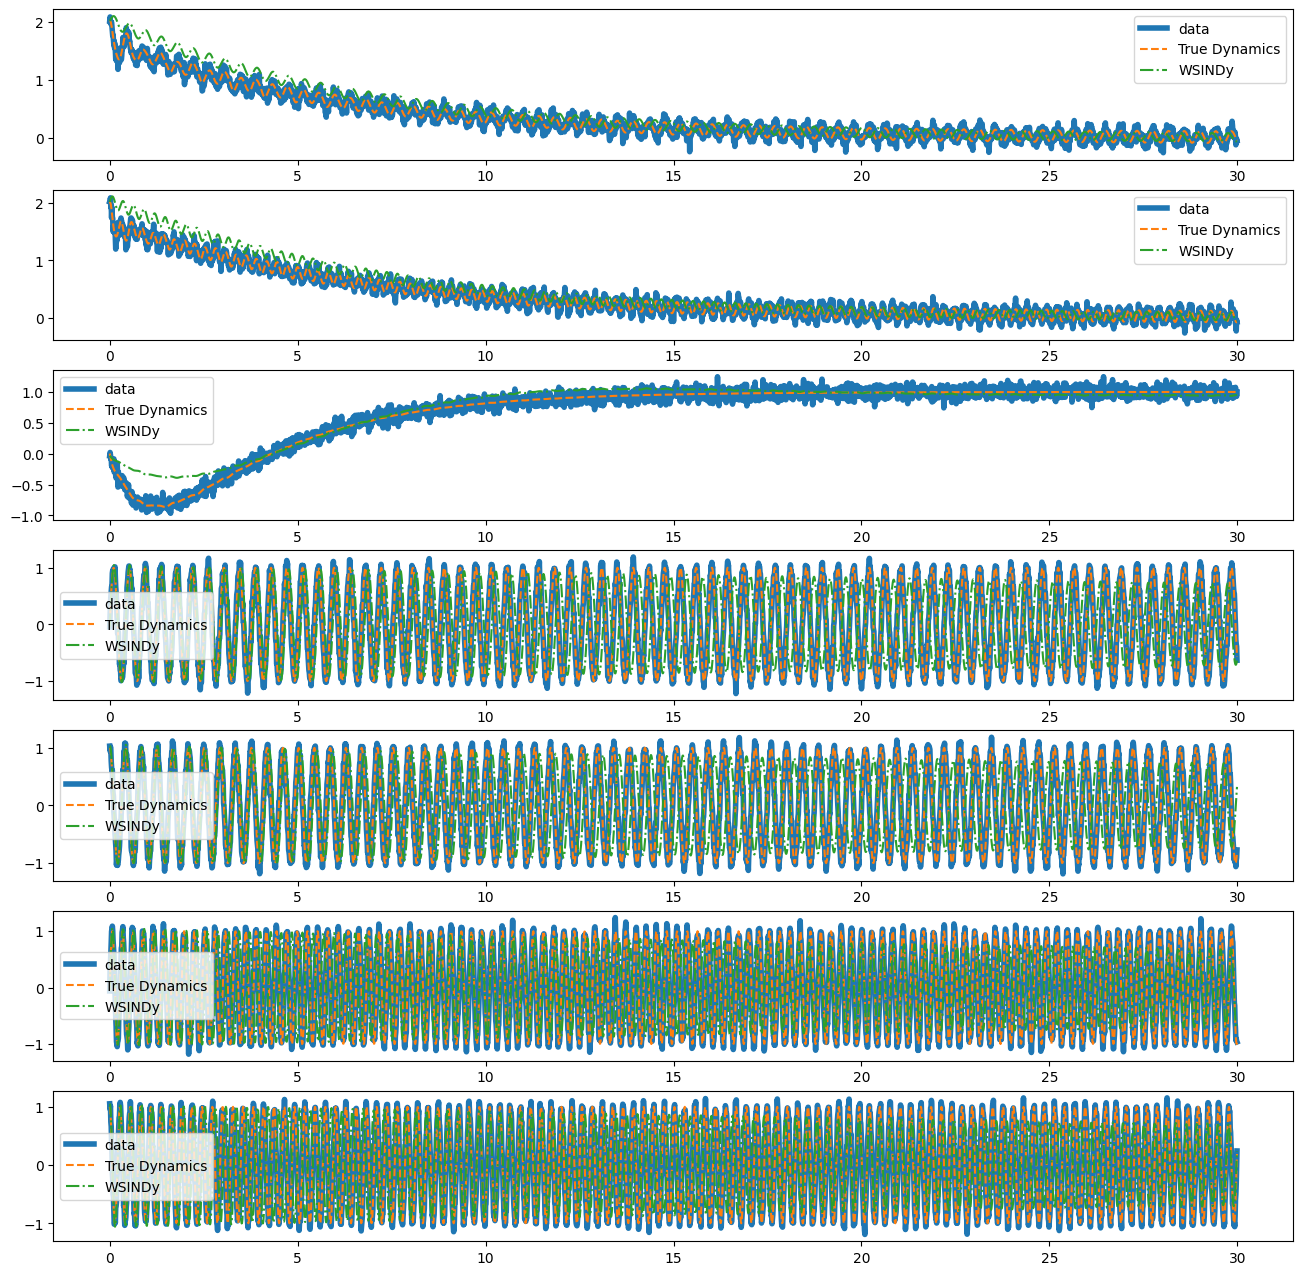

In [8]:
fig = plt.figure(figsize=(16, 16))
c = 1
n = xobs.shape[1]
for d in range(n):
    plt.subplot(n, 1, c)
    plt.plot(t, xobs[:, d], label = "data", linewidth = 4)
    plt.plot(t, x[:, d], linestyle = "--", label = 'True Dynamics',) #marker = 'o', markevery=300)
    plt.plot(t_ws, WSINDy_sim[:, d], linestyle='dashdot', label = 'WSINDy') #marker = 'v', markevery = 200)
    
    c = c + 1
    plt.legend()